### Hi Again now i feel confident with the random forest algorithm so going to implement myself on iris flower dataset which i have already used while learning decision trees

In [69]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [70]:
dataset = load_iris()
dir(dataset)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [71]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [72]:
df['target'] = dataset.target

In [73]:
df[0:12]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [74]:
X = df.drop('target', axis='columns')
y = df.target

In [75]:
from sklearn.model_selection import train_test_split
X_train , X_test ,  y_train , y_test = train_test_split(X,y, test_size=0.2)  

In [76]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=20)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [77]:
model.score(X_test, y_test)

1.0

In [78]:
y_predicted = model.predict(X_test)

In [79]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test , y_predicted)
cm

array([[11,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 10]])

Text(95.72222222222221, 0.5, 'Truth')

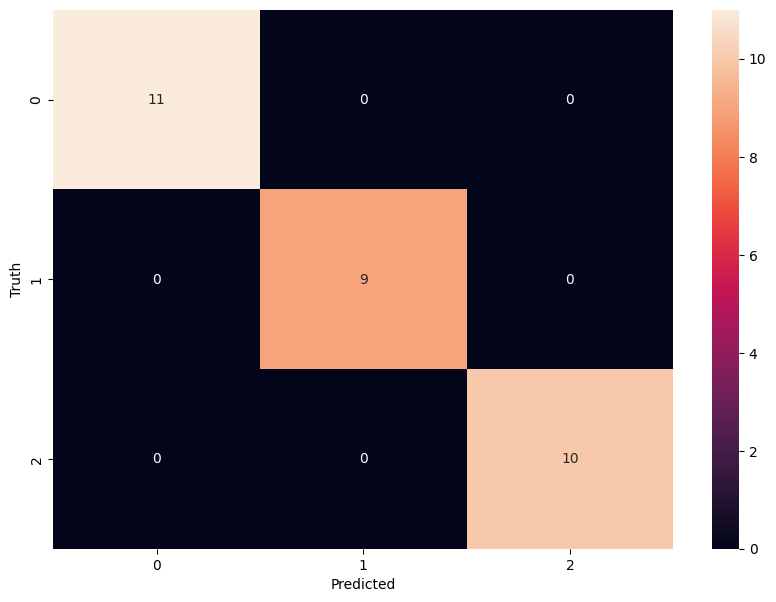

In [80]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [81]:
# Enter one new flower sample manually and predict its class

sepal_length = float(input("Enter sepal length (cm): "))
sepal_width = float(input("Enter sepal width (cm): "))
petal_length = float(input("Enter petal length (cm): "))
petal_width = float(input("Enter petal width (cm): "))

new_sample = pd.DataFrame(
    [[sepal_length, sepal_width, petal_length, petal_width]],
    columns=X.columns
)

prediction = model.predict(new_sample)[0]
predicted_species = dataset.target_names[prediction]

print("\nEntered values:")
print(new_sample)
print(f"\nPredicted species: {predicted_species}")


Entered values:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0               1.25               0.5                3.5               1.5

Predicted species: versicolor


In [82]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Compare predictions with the true labels from the test set
comparison = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_label": y_predicted,
    "correct": y_predicted == y_test.values,
    "true_species": [dataset.target_names[i] for i in y_test.values],
    "predicted_species": [dataset.target_names[i] for i in y_predicted]
})

print("Accuracy:", accuracy_score(y_test, y_predicted))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predicted))
print("\nClassification Report:\n", classification_report(
    y_test,
    y_predicted,
    target_names=dataset.target_names
))

comparison.head(20)

Accuracy: 1.0

Confusion Matrix:
 [[11  0  0]
 [ 0  9  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



,true_label,predicted_label,correct,true_species,predicted_species
0,0,0,True,setosa,setosa
1,0,0,True,setosa,setosa
2,1,1,True,versicolor,versicolor
3,2,2,True,virginica,virginica
4,2,2,True,virginica,virginica
5,1,1,True,versicolor,versicolor
6,2,2,True,virginica,virginica
7,1,1,True,versicolor,versicolor
8,1,1,True,versicolor,versicolor
9,2,2,True,virginica,virginica
